# U-Net Crack Segmentation using Crack500

This notebook implements a U-Net based semantic segmentation pipeline for crack detection using the Crack500 dataset. The objective is to generate pixel-level crack masks from road and pavement surface images.

## Dataset Verification

Before model development, the dataset is inspected to verify image-mask alignment, mask format, image dimensions, and class distribution.

In [1]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.0 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompati

In [50]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import segmentation_models_pytorch as smp
import matplotlib.image as mpimg

In [4]:
IMG_DIR="/kaggle/input/datasets/cvvlearner/a-crack-dataset/Crack segmentation/Crack segmentation/img"
MASK_DIR="/kaggle/input/datasets/cvvlearner/a-crack-dataset/Crack segmentation/Crack segmentation/mask"
print("Images:", len(os.listdir(IMG_DIR)))
print("Masks :", len(os.listdir(MASK_DIR)))

Images: 1625
Masks : 1625


In [5]:
import os

print("First 10 image files:")
print(sorted(os.listdir(IMG_DIR))[:10])

print("\nFirst 10 mask files:")
print(sorted(os.listdir(MASK_DIR))[:10])

First 10 image files:
['025.jpg', '025_1.jpg', '025__1.jpg', '025add1.jpg', '025adjust1.jpg', '025sub1.jpg', '026.jpg', '026_2.jpg', '026__2.jpg', '026add2.jpg']

First 10 mask files:
['025.png', '025_1.png', '025__1.png', '025add1.png', '025adjust1.png', '025sub1.png', '026.png', '026_2.png', '026__2.png', '026add2.png']


/kaggle/input/datasets/cvvlearner/a-crack-dataset/Crack segmentation/Crack segmentation/img
/kaggle/input/datasets/cvvlearner/a-crack-dataset/Crack segmentation/Crack segmentation/mask

In [6]:
sample_image=random.choice(os.listdir(IMG_DIR))
print("Sample File : ",sample_image)

Sample File :  20160328_150932_1921_721.jpg


In [7]:
image=cv2.imread(
    os.path.join(IMG_DIR,sample_image)
)
image=cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

In [8]:
mask_file=sample_image.replace('.jpg','.png')
mask=cv2.imread(
    os.path.join(MASK_DIR,mask_file),
    cv2.IMREAD_GRAYSCALE
)
print("Image Shape : ",image.shape)
print("Mask Shape : ",mask.shape)

Image Shape :  (640, 640, 3)
Mask Shape :  (640, 640)


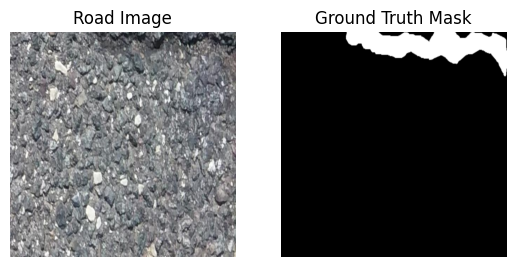

In [9]:
plt.subplot(1,2,1)
plt.imshow(image)
plt.title('Road Image')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(mask,cmap='gray')
plt.title('Ground Truth Mask')
plt.axis('off')
plt.show()

In [10]:
print("Unique mask values:")
print(np.unique(mask))

Unique mask values:
[  0   1   2   3   4   5   6   7   8   9  11  12  13  14  15  17  19  21
  22  23  25  26  27  28  30  31  32  33  34  35  37  40  42  43  47  49
  50  51  54  56  58  62  63  66  67  72  74  77  81  86  88  91  95  98
 104 105 106 109 110 119 120 122 133 136 145 146 150 152 157 160 164 167
 169 170 174 178 181 183 188 189 192 193 198 199 201 206 207 208 213 214
 215 219 220 221 222 223 224 225 226 227 228 229 230 232 233 234 236 238
 240 241 242 243 244 246 248 249 250 251 252 253 254 255]


In [11]:
binary_mask = (mask > 127).astype(np.uint8)
print(np.unique(binary_mask))

[0 1]


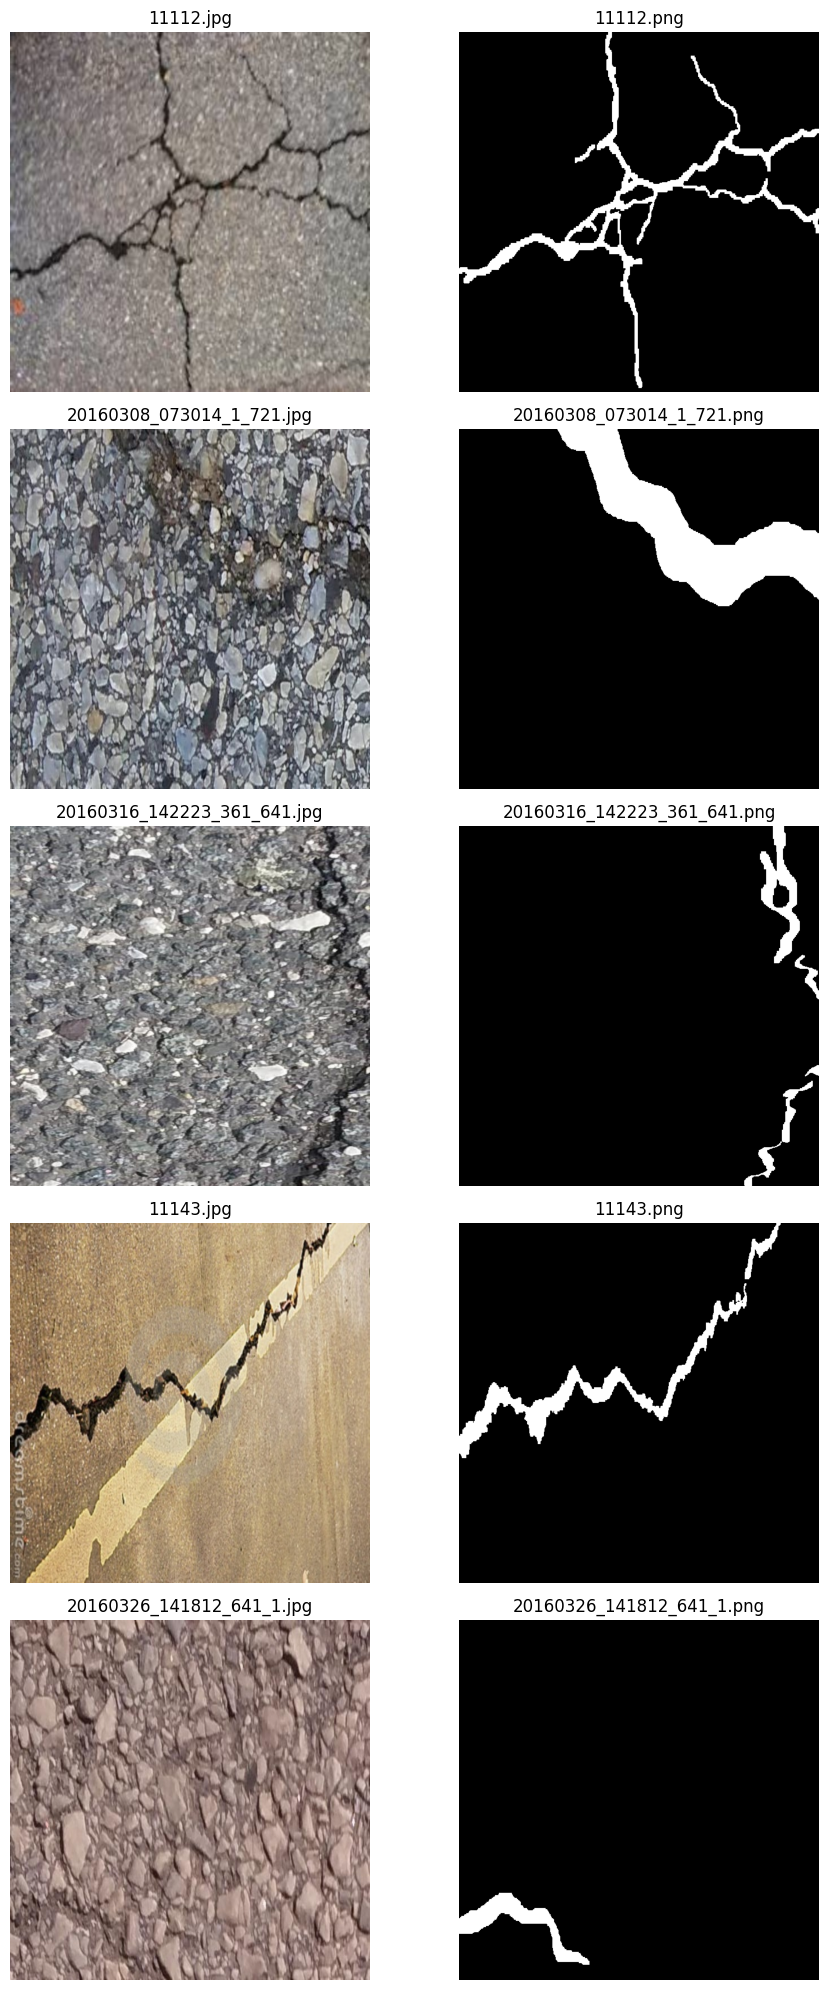

In [12]:
samples=random.sample(
    os.listdir(IMG_DIR),
    5
)
fig, axes = plt.subplots(
    5,
    2,
    figsize=(10,20)
)

for i, image_file in enumerate(samples):

    image = cv2.imread(
        os.path.join(IMG_DIR, image_file)
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )
    mask_file = image_file.replace(
        ".jpg",
        ".png"
    )

    mask = cv2.imread(
        os.path.join(MASK_DIR, mask_file),
        cv2.IMREAD_GRAYSCALE
    )
    mask = (mask > 127).astype(np.uint8)

    axes[i,0].imshow(image)
    axes[i,0].set_title(image_file)
    axes[i,0].axis("off")

    axes[i,1].imshow(mask, cmap="gray")
    axes[i,1].set_title(mask_file)
    axes[i,1].axis("off")

plt.tight_layout()
plt.show()

In [13]:
all_values = set()
for mask_file in os.listdir(MASK_DIR)[:100]:
    
    mask = cv2.imread(
        os.path.join(MASK_DIR, mask_file),
        cv2.IMREAD_GRAYSCALE
    )

    all_values.update(
        np.unique(mask)
    )

print(sorted(all_values))

[np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(16), np.uint8(17), np.uint8(18), np.uint8(19), np.uint8(20), np.uint8(21), np.uint8(22), np.uint8(23), np.uint8(24), np.uint8(25), np.uint8(26), np.uint8(27), np.uint8(28), np.uint8(29), np.uint8(30), np.uint8(31), np.uint8(32), np.uint8(33), np.uint8(34), np.uint8(35), np.uint8(36), np.uint8(37), np.uint8(38), np.uint8(39), np.uint8(40), np.uint8(41), np.uint8(42), np.uint8(43), np.uint8(44), np.uint8(45), np.uint8(46), np.uint8(47), np.uint8(48), np.uint8(49), np.uint8(50), np.uint8(51), np.uint8(52), np.uint8(53), np.uint8(54), np.uint8(55), np.uint8(56), np.uint8(57), np.uint8(58), np.uint8(59), np.uint8(60), np.uint8(61), np.uint8(62), np.uint8(63), np.uint8(64), np.uint8(65), np.uint8(66), np.uint8(67), np.uint8(68), np.uint8(69), np.uint8(70), np.uint8(71), n

In [14]:
total_pixels = 0
crack_pixels = 0
for mask_file in os.listdir(MASK_DIR):

    mask = cv2.imread(
        os.path.join(MASK_DIR, mask_file),
        cv2.IMREAD_GRAYSCALE
    )

    mask = (mask > 127).astype(np.uint8)

    crack_pixels += mask.sum()
    total_pixels += mask.size


print("Crack %:", 100 * crack_pixels / total_pixels)
print("Background %:", 100 - (100 * crack_pixels / total_pixels))

Crack %: 3.5462880108173076
Background %: 96.4537119891827


In [15]:
image_files=sorted(os.listdir(IMG_DIR))

train_files,temp_files=train_test_split(
    image_files,
    test_size=0.2,
    random_state=42
)

val_files,test_files=train_test_split(
    temp_files,
    test_size=0.5,
    random_state=42
)

print("Train : ",len(train_files))
print("Validation : ",len(val_files))
print("Test : ",len(test_files))

Train :  1300
Validation :  162
Test :  163


In [16]:
class CrackDataset(Dataset):
    
    def __init__(self,file_list,img_dir,mask_dir):
        self.file_list = file_list
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        
    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
    
            image_file = self.file_list[idx]
    
            image_path = os.path.join(
                self.img_dir,
                image_file
            )
    
            mask_file = image_file.replace(
                ".jpg",
                ".png"
            )
            mask_path = os.path.join(
                self.mask_dir,
                mask_file
            )
    
            image = cv2.imread(image_path)
            image = cv2.cvtColor(
                image,
                cv2.COLOR_BGR2RGB
            )
    
            mask = cv2.imread(
                mask_path,
                cv2.IMREAD_GRAYSCALE
            )
            image = image.astype(np.float32) / 255.0
            mask = (mask > 127).astype(np.float32)
            image = torch.from_numpy(image).permute(2, 0, 1)
            mask = torch.from_numpy(mask).unsqueeze(0)

            return image, mask

In [17]:
train_dataset=CrackDataset(train_files,IMG_DIR,MASK_DIR)
val_dataset=CrackDataset(val_files,IMG_DIR,MASK_DIR)
test_dataset=CrackDataset(test_files,IMG_DIR,MASK_DIR)

print("Train Dataset : ",len(train_dataset))
print("Val Dataset : ",len(val_dataset))
print("Test Dataset : ",len(test_dataset))

Train Dataset :  1300
Val Dataset :  162
Test Dataset :  163


In [18]:
image,mask=train_dataset[0]

print("Image Shape : ",image.shape)
print("Mask Shape : ",mask.shape)

print("Image Min : ",image.min())
print("Image Max : ",image.max())

print("Mask Unique Values : ")
print(torch.unique(mask))

Image Shape :  torch.Size([3, 640, 640])
Mask Shape :  torch.Size([1, 640, 640])
Image Min :  tensor(0.2235)
Image Max :  tensor(0.9961)
Mask Unique Values : 
tensor([0., 1.])


In [30]:
BATCH_SIZE=8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Train Batches:", len(train_loader))
print("Val Batches:", len(val_loader))
print("Test Batches:", len(test_loader))

Train Batches: 163
Val Batches: 21
Test Batches: 21


In [31]:
images, masks = next(iter(train_loader))

print("Batch Image Shape:", images.shape)
print("Batch Mask Shape :", masks.shape)

Batch Image Shape: torch.Size([8, 3, 640, 640])
Batch Mask Shape : torch.Size([8, 1, 640, 640])


In [32]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [33]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.to(device)

print(model)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [34]:
images, masks = next(
    iter(train_loader)
)

images = images.to(device)

outputs = model(images)

print("Input Shape :", images.shape)
print("Output Shape:", outputs.shape)

Input Shape : torch.Size([8, 3, 640, 640])
Output Shape: torch.Size([8, 1, 640, 640])


In [35]:
class DiceLoss(nn.Module):

    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):

        preds = torch.sigmoid(preds)
        preds = preds.view(-1)
        targets = targets.view(-1)
        intersection = (preds * targets).sum()
        dice=(2.0*intersection+self.smooth)/(preds.sum()+targets.sum()+self.smooth)
        
        return 1-dice
        

In [36]:
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

def combined_loss(preds,targets):
    return (bce_loss(preds, targets)+dice_loss(preds, targets))

In [37]:
optimizer=torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [38]:
images, masks = next(
    iter(train_loader)
)

images = images.to(device)
masks = masks.to(device)

outputs = model(images)

loss = combined_loss(outputs,masks)

print("Loss:",loss.item())


Loss: 1.538567066192627


In [39]:
EPOCHS = 30
train_losses = []
val_losses = []
best_val_loss = float("inf")

In [40]:
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = combined_loss(outputs,masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    model.eval()

    val_loss = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = combined_loss(outputs,masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )


    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(model.state_dict(),"best_unet.pth")

        print("Best model saved!")

Epoch [1/30] Train Loss: 1.1213 Val Loss: 0.8973
Best model saved!
Epoch [2/30] Train Loss: 0.7801 Val Loss: 0.7073
Best model saved!
Epoch [3/30] Train Loss: 0.5791 Val Loss: 0.5300
Best model saved!
Epoch [4/30] Train Loss: 0.4635 Val Loss: 0.4461
Best model saved!
Epoch [5/30] Train Loss: 0.3895 Val Loss: 0.3977
Best model saved!
Epoch [6/30] Train Loss: 0.3409 Val Loss: 0.3688
Best model saved!
Epoch [7/30] Train Loss: 0.3210 Val Loss: 0.3709
Epoch [8/30] Train Loss: 0.3005 Val Loss: 0.3471
Best model saved!
Epoch [9/30] Train Loss: 0.2860 Val Loss: 0.3608
Epoch [10/30] Train Loss: 0.2577 Val Loss: 0.3306
Best model saved!
Epoch [11/30] Train Loss: 0.2445 Val Loss: 0.3181
Best model saved!
Epoch [12/30] Train Loss: 0.2356 Val Loss: 0.3318
Epoch [13/30] Train Loss: 0.2189 Val Loss: 0.3276
Epoch [14/30] Train Loss: 0.2165 Val Loss: 0.3299
Epoch [15/30] Train Loss: 0.2127 Val Loss: 0.3431
Epoch [16/30] Train Loss: 0.2033 Val Loss: 0.3483
Epoch [17/30] Train Loss: 0.2185 Val Loss: 0.32

In [41]:
from IPython.display import FileLink

FileLink("best_unet.pth")

/kaggle/working/best_unet.pth

## Model Evaluation

In [43]:
model.load_state_dict(
    torch.load(
        "best_unet.pth",
        map_location=device
    )
)

model.eval()

print("Best model loaded.")

Best model loaded.


In [45]:
def dice_score(preds,targets,smooth=1):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()

    dice = (2 * intersection + smooth) / (preds.sum() +targets.sum() +smooth)

    return dice.item()

In [46]:
def iou_score(preds,targets,smooth=1):

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()

    union = (preds.sum() +targets.sum() -intersection)

    iou = (intersection + smooth) / (union + smooth)

    return iou.item()

In [47]:
total_dice = 0
total_iou = 0

model.eval()

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        total_dice += dice_score(outputs,masks)

        total_iou += iou_score(outputs,masks)

avg_dice = total_dice / len(test_loader)
avg_iou = total_iou / len(test_loader)

print(f"Average Dice Score: {avg_dice:.4f}")

print(f"Average IoU Score: {avg_iou:.4f}")

Average Dice Score: 0.7533
Average IoU Score: 0.6118


In [48]:
os.makedirs("unet_prediction_examples",exist_ok=True)

In [49]:
indices = random.sample(range(len(test_dataset)),10)

for idx_num, idx in enumerate(indices, start=1):

    image, mask = test_dataset[idx]

    image_batch = image.unsqueeze(0).to(device)

    with torch.no_grad():

        pred = model(image_batch)

        pred = torch.sigmoid(pred)

        pred = (pred > 0.5).float()

    image_np = image.permute(1,2,0).cpu().numpy()

    mask_np = mask.squeeze().cpu().numpy()

    pred_np = pred.squeeze().cpu().numpy()

    fig, axes = plt.subplots(1,3,figsize=(15,5))

    axes[0].imshow(image_np)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(
        mask_np,
        cmap="gray"
    )
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(
        pred_np,
        cmap="gray"
    )
    axes[2].set_title("Prediction")
    axes[2].axis("off")

    plt.tight_layout()

    plt.savefig(f"unet_prediction_examples/example_{idx_num}.png",dpi=300)

    plt.close()

print("Prediction figures saved.")

Prediction figures saved.


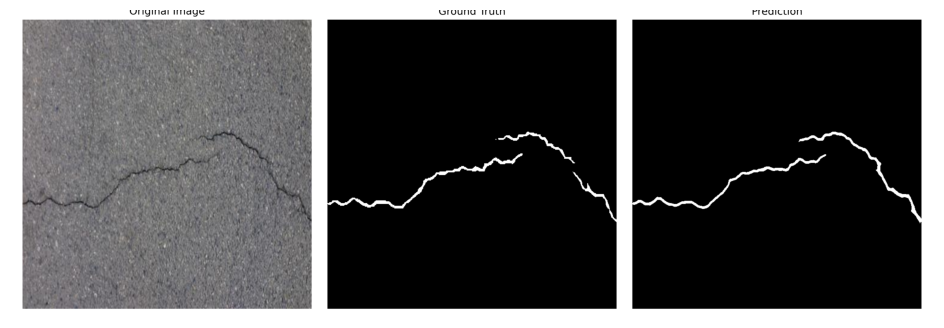

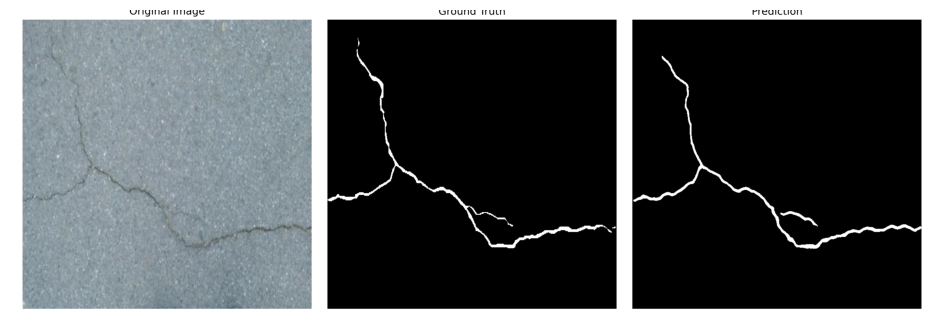

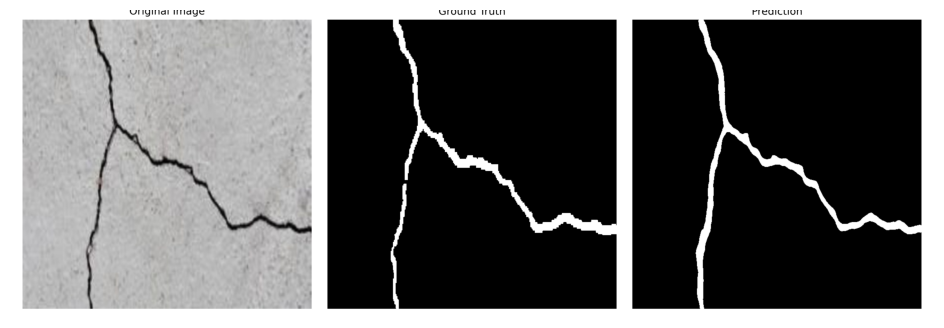

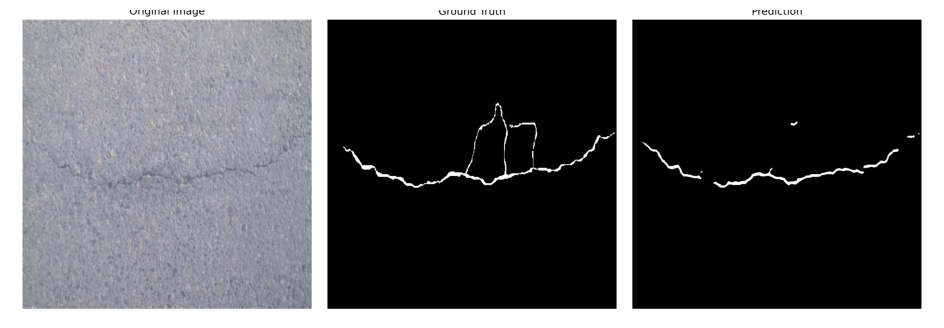

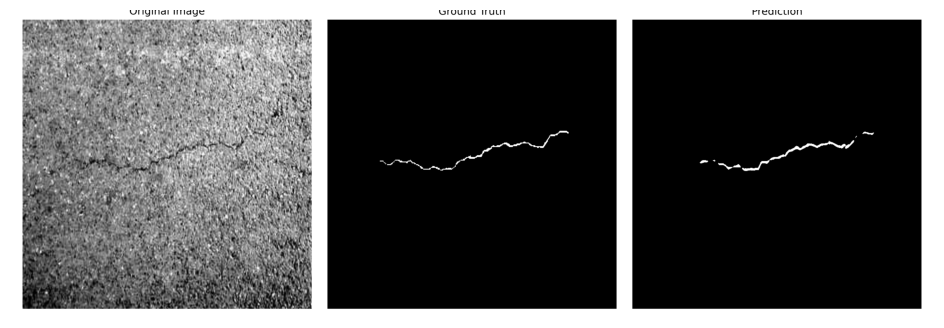

In [51]:
for i in range(1,6):

    img = mpimg.imread(f"unet_prediction_examples/example_{i}.png")

    plt.figure(figsize=(12,4))

    plt.imshow(img)

    plt.axis("off")

    plt.show()

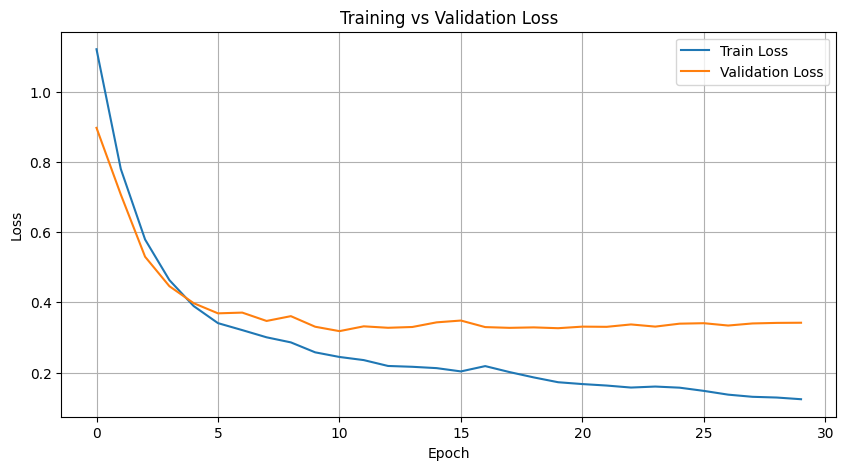

In [52]:
plt.figure(figsize=(10,5))

plt.plot(train_losses,label="Train Loss")

plt.plot(val_losses,label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.savefig("loss_curve.png",dpi=300)

plt.show()